## Setup — Load Artifacts from Phase 2

In [1]:
# ============================================================
# Install dependencies & restart runtime
# Run this cell, then go to Runtime > Restart session
# ============================================================
!pip install datasets==2.14.7 huggingface_hub==0.21.4 transformers==4.40.2 -q
!pip install underthesea scikit-learn -q
print("✅ Done. Now go to Runtime > Restart session, then run the next cell.")

✅ Done. Now go to Runtime > Restart session, then run the next cell.


In [2]:
# ============================================================
# Import libraries and load all saved artifacts from Phase 2
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import json
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis'
DATA_DIR = f'{BASE_DIR}/data'

LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']
NUM_CLASSES = 3

# Load test data with predictions
test_df = pd.read_csv(f'{DATA_DIR}/test_with_predictions.csv')

# Load training history and results table
with open(f'{BASE_DIR}/training_history.json', 'r') as f:
    history = json.load(f)

results_df = pd.read_csv(f'{BASE_DIR}/model_results.csv')

print(f"Test set: {len(test_df):,} samples")
print(f"Columns: {list(test_df.columns)}")
print(f"\nResults from Phase 2:")
print(results_df.to_string(index=False))

Mounted at /content/drive
Test set: 3,166 samples
Columns: ['sentence', 'sentiment', 'topic', 'label_name', 'clean_text', 'phobert_pred']

Results from Phase 2:
               model  val_accuracy  test_accuracy  test_f1_macro
     TF-IDF + LogReg      0.909665       0.890398       0.645653
PhoBERT (fine-tuned)      0.955780       0.939672       0.827183


## 3.1 Error Analysis

In [3]:
# ============================================================
# Extract misclassified samples — overall error rate and count
# ============================================================
test_df['correct'] = test_df['sentiment'] == test_df['phobert_pred']
test_df['true_label'] = test_df['sentiment'].map(LABEL_MAP)
test_df['pred_label'] = test_df['phobert_pred'].map(LABEL_MAP)

errors_df = test_df[~test_df['correct']].copy()
correct_df = test_df[test_df['correct']].copy()

total = len(test_df)
n_errors = len(errors_df)

print(f"Total test samples: {total:,}")
print(f"Correct:            {total - n_errors:,} ({(total - n_errors)/total:.1%})")
print(f"Errors:             {n_errors:,} ({n_errors/total:.1%})")

Total test samples: 3,166
Correct:            2,975 (94.0%)
Errors:             191 (6.0%)


In [4]:
# ============================================================
# Error breakdown by confusion pair (true → predicted)
# Identifies which class confusions dominate the errors
# ============================================================
confusion_pairs = (
    errors_df
    .groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

confusion_pairs['percentage'] = (confusion_pairs['count'] / n_errors * 100).round(1)

print("Error breakdown by confusion pair:")
print("=" * 50)
for _, row in confusion_pairs.iterrows():
    print(f"  {row['true_label']:>8s} → {row['pred_label']:<8s}  {row['count']:>4d} ({row['percentage']}%)")

Error breakdown by confusion pair:
   Neutral → Positive    59 (30.9%)
  Positive → Negative    42 (22.0%)
   Neutral → Negative    28 (14.7%)
  Negative → Positive    27 (14.1%)
  Negative → Neutral     22 (11.5%)
  Positive → Neutral     13 (6.8%)


In [5]:
# ============================================================
# Show example misclassified texts for the top confusion pairs
# Reading these builds intuition about what the model struggles with
# ============================================================
top_pairs = confusion_pairs.head(3)

for _, row in top_pairs.iterrows():
    true_l = row['true_label']
    pred_l = row['pred_label']
    subset = errors_df[(errors_df['true_label'] == true_l) & (errors_df['pred_label'] == pred_l)]

    print(f"\n{'='*60}")
    print(f"  {true_l} → {pred_l}  ({len(subset)} errors)")
    print(f"{'='*60}")

    for i, (_, sample) in enumerate(subset.head(5).iterrows()):
        print(f"\n  [{i+1}] {sample['sentence']}")


  Neutral → Positive  (59 errors)

  [1] môn học này giúp chúng em hiểu ra những vấn đề cơ bản .

  [2] như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết .

  [3] ví dụ phù hợp với nội dung kiến thức , hướng dẫn chi tiết .

  [4] kỹ những chương cuối .

  [5] cô cho em 10 điểm thực hành colonlove .

  Positive → Negative  (42 errors)

  [1] trong trường macbook thầy số hai thì không có máy nào số một .

  [2] phần lớn chỉ là lý thuyết và bài tập .

  [3] giảng bài xúc tích .

  [4] cần có nhiều giảng viên như cô dạy hơn .

  [5] cô hoàng toàn không dùng courses hay các phương tiện liên lạc thông báo .

  Neutral → Negative  (28 errors)

  [1] nhiều bài thuyết trình .

  [2] em nghĩ như vậy sẽ tốt hơn vì họ sẽ biết được khả năng của sinh viên trong lớp tới đâu để cho bài thực hành được phù hợp với trình độ của sinh viên .

  [3] chúng em đã nghỉ khoảng 4 tuần như thế .

  [4] thầy có vẻ hơi bận rộn , gặp thầy có vẻ khó .

  [5] cầu kỳ .


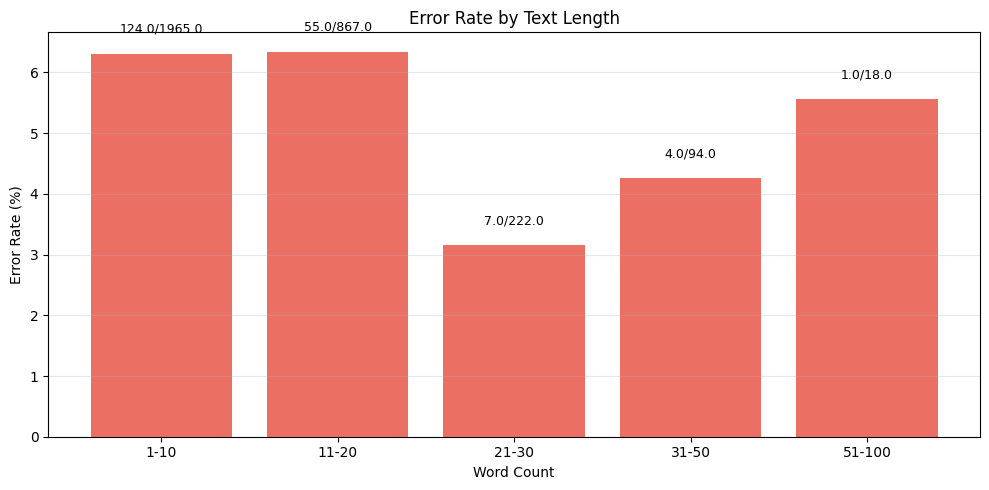

In [6]:
# ============================================================
# Error rate by text length — check if short/long texts are harder
# ============================================================
test_df['word_count'] = test_df['clean_text'].str.split().str.len()

bins = [0, 10, 20, 30, 50, 100, float('inf')]
bin_labels = ['1-10', '11-20', '21-30', '31-50', '51-100', '100+']
test_df['length_bin'] = pd.cut(test_df['word_count'], bins=bins, labels=bin_labels)

length_stats = (
    test_df
    .groupby('length_bin', observed=False)
    .agg(
        total=('correct', 'count'),
        errors=('correct', lambda x: (~x).sum()),
        error_rate=('correct', lambda x: (~x).mean())
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(length_stats.index, length_stats['error_rate'] * 100, color='#e74c3c', alpha=0.8)
ax.set_xlabel('Word Count')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Text Length')
ax.grid(axis='y', alpha=0.3)

for bar, (_, row) in zip(bars, length_stats.iterrows()):
    if row['total'] > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{row['errors']}/{row['total']}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/error_rate_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

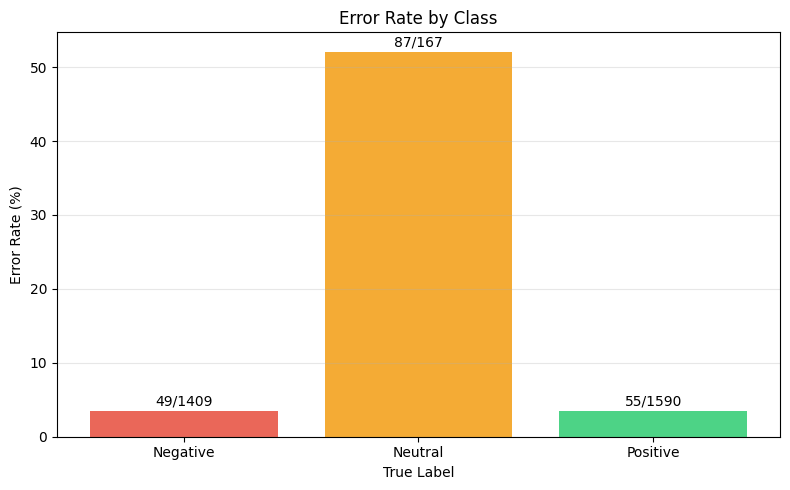

In [7]:
# ============================================================
# Error rate per class — which class is hardest to predict
# ============================================================
class_stats = (
    test_df
    .groupby('true_label')
    .agg(
        total=('correct', 'count'),
        correct=('correct', 'sum'),
        error_rate=('correct', lambda x: (~x).mean())
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(class_stats.index, class_stats['error_rate'] * 100, color=colors, alpha=0.85)
ax.set_xlabel('True Label')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Class')
ax.grid(axis='y', alpha=0.3)

for bar, (_, row) in zip(bars, class_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{int(row['total'] - row['correct'])}/{int(row['total'])}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/error_rate_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# Confidence analysis — reload model and get softmax probabilities
# High-confidence errors are more dangerous than low-confidence ones
# ============================================================
MAX_LENGTH = 128
BATCH_SIZE = 32
CHECKPOINT_DIR = f'{BASE_DIR}/checkpoints'

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_DIR)
best_model.to(device)
best_model.eval()

class VietnameseSentimentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['clean_text'].tolist()
        self.labels = dataframe['sentiment'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_dataset = VietnameseSentimentDataset(test_df, tokenizer, MAX_LENGTH)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

all_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Getting probabilities"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
test_df['confidence'] = all_probs.max(axis=1)
test_df['prob_negative'] = all_probs[:, 0]
test_df['prob_neutral'] = all_probs[:, 1]
test_df['prob_positive'] = all_probs[:, 2]

print(f"Confidence stats:")
print(f"  Overall mean:    {test_df['confidence'].mean():.4f}")
print(f"  Correct mean:    {test_df[test_df['correct']]['confidence'].mean():.4f}")
print(f"  Incorrect mean:  {test_df[~test_df['correct']]['confidence'].mean():.4f}")

Getting probabilities:   0%|          | 0/99 [00:00<?, ?it/s]

Confidence stats:
  Overall mean:    0.9803
  Correct mean:    0.9860
  Incorrect mean:  0.8918


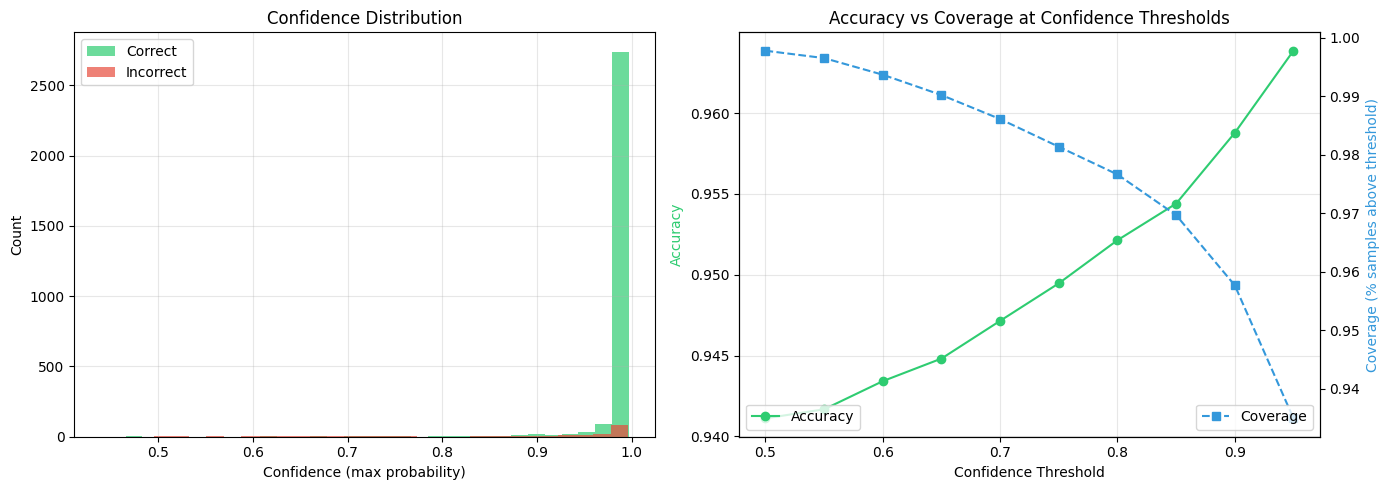

In [9]:
# ============================================================
# Confidence distribution — correct vs incorrect predictions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct_df.index.map(lambda i: test_df.loc[i, 'confidence']),
             bins=30, alpha=0.7, label='Correct', color='#2ecc71')
axes[0].hist(errors_df.index.map(lambda i: test_df.loc[i, 'confidence']),
             bins=30, alpha=0.7, label='Incorrect', color='#e74c3c')
axes[0].set_xlabel('Confidence (max probability)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy at different confidence thresholds
thresholds = np.arange(0.5, 1.0, 0.05)
accs_at_threshold = []
coverage_at_threshold = []
for t in thresholds:
    mask = test_df['confidence'] >= t
    if mask.sum() > 0:
        accs_at_threshold.append(test_df[mask]['correct'].mean())
        coverage_at_threshold.append(mask.mean())
    else:
        accs_at_threshold.append(np.nan)
        coverage_at_threshold.append(0)

ax2 = axes[1]
ax2.plot(thresholds, accs_at_threshold, 'o-', color='#2ecc71', label='Accuracy')
ax2_twin = ax2.twinx()
ax2_twin.plot(thresholds, coverage_at_threshold, 's--', color='#3498db', label='Coverage')
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Accuracy', color='#2ecc71')
ax2_twin.set_ylabel('Coverage (% samples above threshold)', color='#3498db')
ax2.set_title('Accuracy vs Coverage at Confidence Thresholds')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left')
ax2_twin.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# High-confidence errors — the most concerning mistakes
# These are cases where the model is confident but wrong
# ============================================================
high_conf_errors = errors_df.merge(
    test_df[['confidence', 'prob_negative', 'prob_neutral', 'prob_positive']],
    left_index=True, right_index=True
).sort_values('confidence', ascending=False)

print(f"High-confidence errors (confidence > 0.9):")
print(f"{'='*70}")

hc = high_conf_errors[high_conf_errors['confidence'] > 0.9]
print(f"Count: {len(hc)} / {n_errors} total errors ({len(hc)/n_errors:.1%})\n")

for i, (_, row) in enumerate(hc.head(8).iterrows()):
    print(f"[{i+1}] conf={row['confidence']:.3f}  |  {row['true_label']} → {row['pred_label']}")
    print(f"    {row['sentence'][:120]}")
    print()

High-confidence errors (confidence > 0.9):
Count: 125 / 191 total errors (65.4%)

[1] conf=0.996  |  Negative → Positive
    dạy liên hệ thực tế , giảng dễ hiểu .

[2] conf=0.996  |  Neutral → Positive
    thầy giảng nhiệt tình , sát trọng tâm , dễ hiểu , mong thầy kỳ sau sẽ dạy môn xác xuất thống kê .

[3] conf=0.996  |  Negative → Positive
    giảng viên thực hành nhiều bài thực hành trực quan , giảng dễ hiểu .

[4] conf=0.996  |  Neutral → Positive
    ví dụ phù hợp với nội dung kiến thức , hướng dẫn chi tiết .

[5] conf=0.996  |  Neutral → Positive
    nói dễ nghe .

[6] conf=0.996  |  Negative → Positive
    dạy dễ hiểu , không bị rối .

[7] conf=0.996  |  Neutral → Positive
    giáo viên tạo nhiều cơ hội cho sinh viên được luyện nói tiếng anh trên lớp .

[8] conf=0.996  |  Neutral → Positive
    giáo viên truyền đạt kinh nghiệm thực tế nhiều .



## 3.2 Model Comparison

In [11]:
# ============================================================
# Recompute per-class F1 for both models side by side
# Need baseline predictions — rerun TF-IDF + LogReg quickly
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_df = pd.read_csv(f'{DATA_DIR}/train_preprocessed.csv')

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, train_df['sentiment'])

baseline_preds = lr_model.predict(X_test_tfidf)
test_df['baseline_pred'] = baseline_preds

print("Baseline retrained for per-class comparison.")

Baseline retrained for per-class comparison.


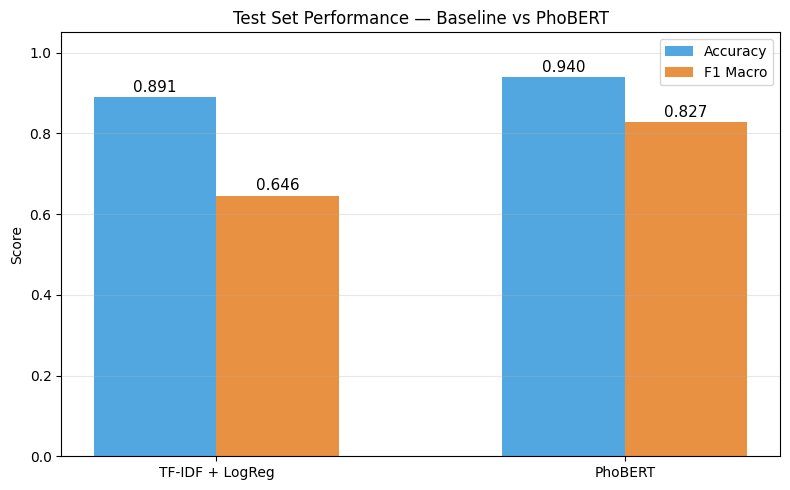

In [12]:
# ============================================================
# Overall metrics comparison — bar chart
# ============================================================
models = ['TF-IDF + LogReg', 'PhoBERT']
test_accs = [
    accuracy_score(test_df['sentiment'], test_df['baseline_pred']),
    accuracy_score(test_df['sentiment'], test_df['phobert_pred'])
]
test_f1s = [
    f1_score(test_df['sentiment'], test_df['baseline_pred'], average='macro'),
    f1_score(test_df['sentiment'], test_df['phobert_pred'], average='macro')
]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(models))
w = 0.3

bars1 = ax.bar(x - w/2, test_accs, w, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, test_f1s, w, label='F1 Macro', color='#e67e22', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('Test Set Performance — Baseline vs PhoBERT')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/model_comparison_overall.png', dpi=150, bbox_inches='tight')
plt.show()

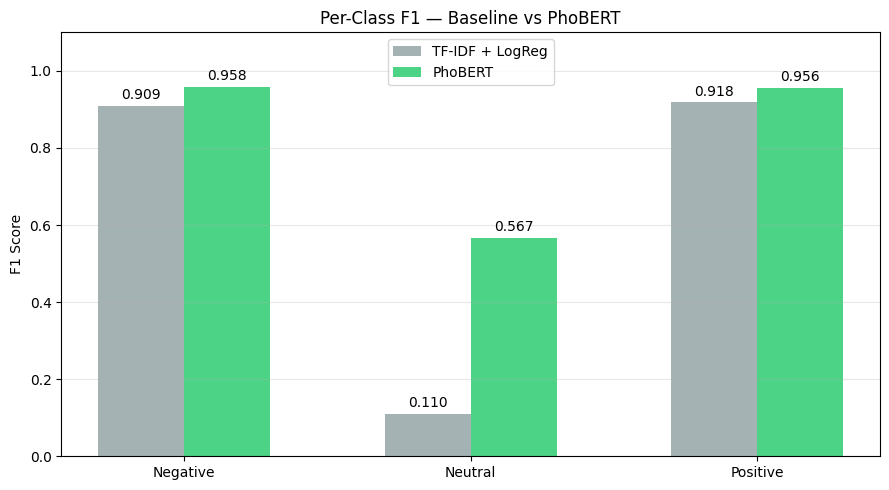


F1 improvement (PhoBERT - Baseline):
  Negative: 0.909 → 0.958 (+0.049)
  Neutral: 0.110 → 0.567 (+0.457)
  Positive: 0.918 → 0.956 (+0.038)


In [13]:
# ============================================================
# Per-class F1 comparison — shows where PhoBERT improved most
# ============================================================
from sklearn.metrics import f1_score as f1_per_class

baseline_f1_per_class = f1_per_class(test_df['sentiment'], test_df['baseline_pred'], average=None)
phobert_f1_per_class = f1_per_class(test_df['sentiment'], test_df['phobert_pred'], average=None)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(NUM_CLASSES)
w = 0.3

bars1 = ax.bar(x - w/2, baseline_f1_per_class, w, label='TF-IDF + LogReg', color='#95a5a6', alpha=0.85)
bars2 = ax.bar(x + w/2, phobert_f1_per_class, w, label='PhoBERT', color='#2ecc71', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 — Baseline vs PhoBERT')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/model_comparison_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Show improvement
print("\nF1 improvement (PhoBERT - Baseline):")
for i, label in enumerate(LABEL_NAMES):
    diff = phobert_f1_per_class[i] - baseline_f1_per_class[i]
    print(f"  {label}: {baseline_f1_per_class[i]:.3f} → {phobert_f1_per_class[i]:.3f} ({diff:+.3f})")

In [14]:
# ============================================================
# Summary table — final results for the report
# ============================================================
summary = pd.DataFrame({
    'Model': models,
    'Test Accuracy': [f"{a:.4f}" for a in test_accs],
    'Test F1 (Macro)': [f"{f:.4f}" for f in test_f1s],
    'F1 Negative': [f"{baseline_f1_per_class[0]:.4f}", f"{phobert_f1_per_class[0]:.4f}"],
    'F1 Neutral': [f"{baseline_f1_per_class[1]:.4f}", f"{phobert_f1_per_class[1]:.4f}"],
    'F1 Positive': [f"{baseline_f1_per_class[2]:.4f}", f"{phobert_f1_per_class[2]:.4f}"],
})

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(summary.to_string(index=False))

acc_improvement = test_accs[1] - test_accs[0]
f1_improvement = test_f1s[1] - test_f1s[0]
best_class_idx = np.argmax(phobert_f1_per_class - baseline_f1_per_class)

print(f"\nKey findings:")
print(f"  • PhoBERT improves accuracy by {acc_improvement:+.4f} over baseline")
print(f"  • PhoBERT improves macro F1 by {f1_improvement:+.4f} over baseline")
print(f"  • Largest per-class gain: {LABEL_NAMES[best_class_idx]}")
print(f"  • Remaining weakness: Neutral class (smallest, most ambiguous)")

FINAL MODEL COMPARISON
          Model Test Accuracy Test F1 (Macro) F1 Negative F1 Neutral F1 Positive
TF-IDF + LogReg        0.8907          0.6459      0.9090     0.1105      0.9181
        PhoBERT        0.9397          0.8272      0.9581     0.5674      0.9561

Key findings:
  • PhoBERT improves accuracy by +0.0490 over baseline
  • PhoBERT improves macro F1 by +0.1813 over baseline
  • Largest per-class gain: Neutral
  • Remaining weakness: Neutral class (smallest, most ambiguous)


In [15]:
# ============================================================
# Save final analysis artifacts
# ============================================================
summary.to_csv(f'{BASE_DIR}/final_comparison.csv', index=False)
test_df.to_csv(f'{DATA_DIR}/test_full_analysis.csv', index=False)

print("Saved: final_comparison.csv, test_full_analysis.csv")

Saved: final_comparison.csv, test_full_analysis.csv
